# Local Model Playground

Interactive notebook to pick a local VLM and run a single 2AFC trial on GPU.

In [11]:
# Cell 1 — Setup & imports
import os
import sys
import gc
from pathlib import Path
import base64
from io import BytesIO

import torch

# Ensure the repo root is on sys.path so we can import evaluation_pipe
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dotenv import load_dotenv
load_dotenv()  # loads HF_TOKEN, IMAGE_DATASET, etc.

from PIL import Image
from IPython.display import display, HTML

from evaluation_pipe.models import create_model, list_models
from evaluation_pipe.models.base import ModelResponse
from evaluation_pipe.data import load_trials

IMAGE_DATASET = REPO_ROOT / os.environ["IMAGE_DATASET"]
print(f"Imports OK — IMAGE_DATASET={IMAGE_DATASET}")

THUMB_SIZE = 200

def _img_to_b64(img: Image.Image, size: int = THUMB_SIZE) -> str:
    thumb = img.copy()
    thumb.thumbnail((size, size))
    buf = BytesIO()
    thumb.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

def show_trial(ref, img_a, img_b, a_label="A", b_label="B"):
    cells = ""
    for img, label in [(ref, "Reference"), (img_a, a_label), (img_b, b_label)]:
        b64 = _img_to_b64(img)
        cells += f'<td style="text-align:center"><b>{label}</b><br><img src="data:image/png;base64,{b64}"></td>'
    display(HTML(f"<table><tr>{cells}</tr></table>"))

Imports OK — IMAGE_DATASET=/spark2/julio/langcog_hackathon/shapebias-bench/stimuli_pipe/stimuli_per_stl_packages/stimuli_A_auto_contrast


In [12]:
DEVICE = "cuda"
PROMPT = (
    "You are given three images. The first image is the reference. "
    "Which of the other two images (A or B) is more similar to the reference? "
    "Answer with just 'A' or 'B'."
)
print("Available models:", list_models())

# Load trial 1 for testing all models
trials = load_trials(IMAGE_DATASET, order="shape_first")
trial = trials[0]
print(f"Using trial {trial.trial_id} (ground_truth={trial.ground_truth})")

Available models: ['internvl', 'qwen3-vl-2b', 'qwen3-vl-4b', 'qwen3.5-0.8b', 'qwen3.5-4b', 'smolvlm']
Using trial 1 (ground_truth=A)


## SmolVLM

Reference,A (shape_match),B (texture_match)

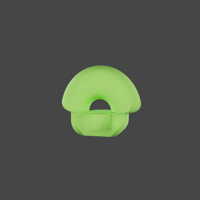
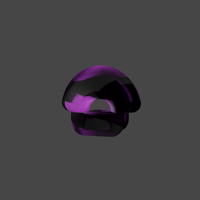
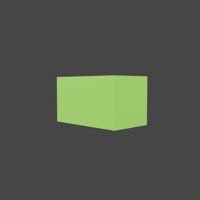

In [ ]:
reference, image_a, image_b = trial.load_images()
display(HTML("<b>Reference | Image A (shape_match) | Image B (texture_match)</b>"))
show_trial(reference, image_a, image_b, "A (shape_match)", "B (texture_match)")

In [14]:
model = create_model("smolvlm", device=DEVICE)
print(f"Loaded: {model.name}")
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 657/657 [00:00<00:00, 3004.74it/s]


Loaded: HuggingFaceTB/SmolVLM2-2.2B-Instruct
Answer: A
Time:   1.88s
Tokens: 2


In [15]:
model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("SmolVLM unloaded — GPU memory freed.")

SmolVLM unloaded — GPU memory freed.


## InternVL

Reference,A (shape_match),B (texture_match)

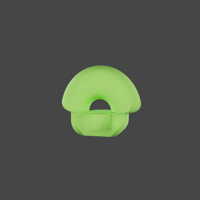
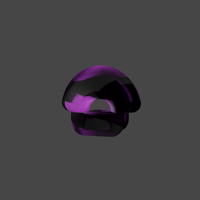
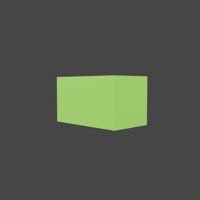

In [16]:
reference, image_a, image_b = trial.load_images()
display(HTML("<b>Reference | Image A (shape_match) | Image B (texture_match)</b>"))
show_trial(reference, image_a, image_b, "A (shape_match)", "B (texture_match)")

In [17]:
model = create_model("internvl", device=DEVICE)
print(f"Loaded: {model.name}")
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}
Loading weights: 100%|██████████| 733/733 [00:08<00:00, 81.76it/s] 
The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Loaded: OpenGVLab/InternVL3-1B-hf
Answer: A
Time:   0.70s
Tokens: 2


In [18]:
model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("InternVL unloaded — GPU memory freed.")

InternVL unloaded — GPU memory freed.


## Qwen3-VL-2B

Reference,A (shape_match),B (texture_match)

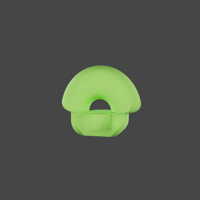
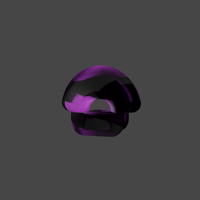
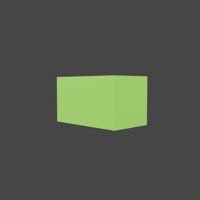

In [19]:
reference, image_a, image_b = trial.load_images()
display(HTML("<b>Reference | Image A (shape_match) | Image B (texture_match)</b>"))
show_trial(reference, image_a, image_b, "A (shape_match)", "B (texture_match)")

In [20]:
model = create_model("qwen3-vl-2b", device=DEVICE)
print(f"Loaded: {model.name}")
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

Loading weights: 100%|██████████| 625/625 [00:20<00:00, 29.80it/s] 
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loaded: Qwen/Qwen3-VL-2B-Instruct
Answer: A
Time:   0.79s
Tokens: 2


In [21]:
model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("Qwen3-VL-2B unloaded — GPU memory freed.")

Qwen3-VL-2B unloaded — GPU memory freed.


## Qwen3-VL-4B

Reference,A (shape_match),B (texture_match)

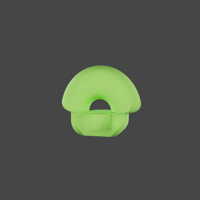
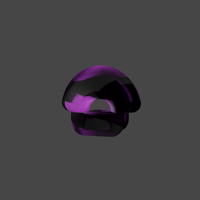
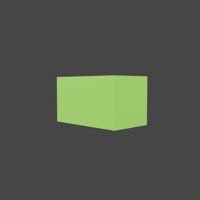

In [22]:
reference, image_a, image_b = trial.load_images()
display(HTML("<b>Reference | Image A (shape_match) | Image B (texture_match)</b>"))
show_trial(reference, image_a, image_b, "A (shape_match)", "B (texture_match)")

In [23]:
model = create_model("qwen3-vl-4b", device=DEVICE)
print(f"Loaded: {model.name}")
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

Loading weights: 100%|██████████| 713/713 [00:42<00:00, 16.61it/s]


Loaded: Qwen/Qwen3-VL-4B-Instruct
Answer: A
Time:   1.13s
Tokens: 2


In [24]:
model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("Qwen3-VL-4B unloaded — GPU memory freed.")

Qwen3-VL-4B unloaded — GPU memory freed.


## Qwen3.5-0.8B

Reference,A (shape_match),B (texture_match)

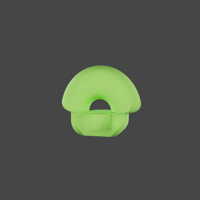
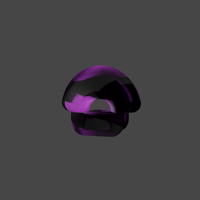
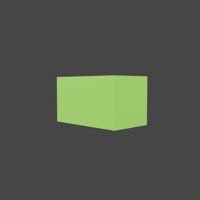

In [25]:
reference, image_a, image_b = trial.load_images()
display(HTML("<b>Reference | Image A (shape_match) | Image B (texture_match)</b>"))
show_trial(reference, image_a, image_b, "A (shape_match)", "B (texture_match)")

In [26]:
model = create_model("qwen3.5-0.8b", device=DEVICE)
print(f"Loaded: {model.name}")
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 473/473 [00:07<00:00, 59.96it/s] 
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Loaded: Qwen/Qwen3.5-0.8B
Answer: B
Time:   0.76s
Tokens: 4


In [27]:
model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("Qwen3.5-0.8B unloaded — GPU memory freed.")

Qwen3.5-0.8B unloaded — GPU memory freed.


## Qwen3.5-4B

Reference,A (shape_match),B (texture_match)

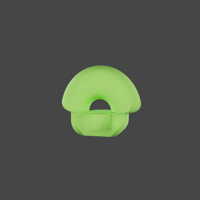
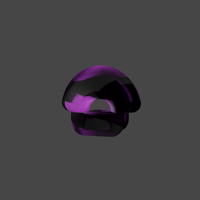
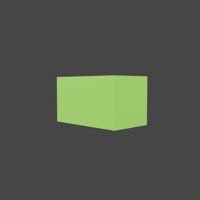

In [28]:
reference, image_a, image_b = trial.load_images()
display(HTML("<b>Reference | Image A (shape_match) | Image B (texture_match)</b>"))
show_trial(reference, image_a, image_b, "A (shape_match)", "B (texture_match)")

In [29]:
model = create_model("qwen3.5-4b", device=DEVICE)
print(f"Loaded: {model.name}")
response = model.generate(images=[reference, image_a, image_b], prompt=PROMPT)
print(f"Answer: {response.raw_text}")
print(f"Time:   {response.generation_time_s:.2f}s")
print(f"Tokens: {response.num_tokens_generated}")

Loading weights: 100%|██████████| 723/723 [00:47<00:00, 15.29it/s] 
Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Loaded: Qwen/Qwen3.5-4B
Answer: A
Time:   2.11s
Tokens: 4


In [30]:
model.unload()
del model, reference, image_a, image_b
gc.collect()
torch.cuda.empty_cache()
print("Qwen3.5-4B unloaded — GPU memory freed.")

Qwen3.5-4B unloaded — GPU memory freed.
